In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set(style="whitegrid")
print("All required libraries imported successfully.")

All required libraries imported successfully.


In [25]:
#load datasets
try:
    df_sales = pd.read_csv('sales_data.csv')
    df_churn = pd.read_csv('customer_churn.csv')
    print("Datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading datasets. Files not found: {e}")

#Data Cleaning
df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'], errors='coerce').fillna(0)

#Data preview
display(df_sales.head())
display(df_churn.head())


Datasets loaded successfully.


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [26]:
print("Descriptive Statistics for Sales Data:")
desc_stats = df_sales['Total_Sales'].describe()

print(f"Mean Sales: ${desc_stats['mean']:,.2f}")
print(f"Median Sales: ${desc_stats['50%']:,.2f}")
print(f"Standard Deviation of Sales: ${desc_stats['std']:,.2f}")
print(f"Min Sales; ${desc_stats['min']:,.2f}")
print(f"Max Sales: ${desc_stats['max']:,.2f}")

Descriptive Statistics for Sales Data:
Mean Sales: $123,650.48
Median Sales: $97,955.50
Standard Deviation of Sales: $100,161.09
Min Sales; $6,540.00
Max Sales: $373,932.00


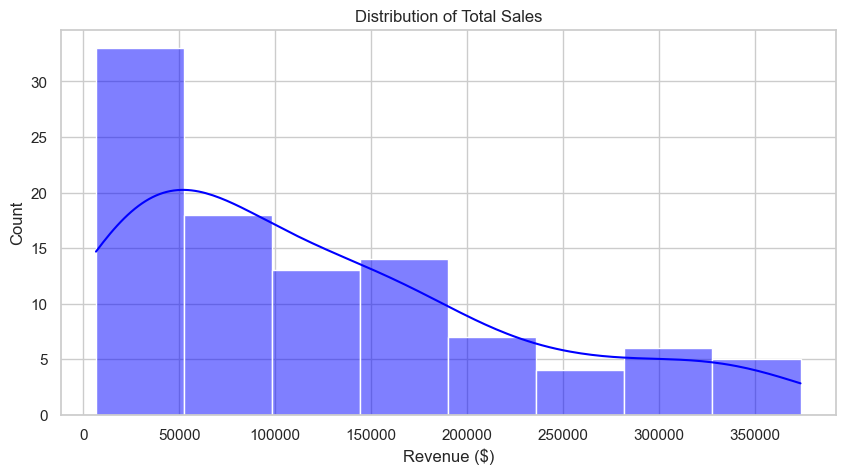

Normality Test P-value: 0.00000
Conclusion: Data is NOT normally distributed (Reject H0)


In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(df_sales['Total_Sales'], kde=True, color='blue')
plt.title('Distribution of Total Sales')
plt.xlabel('Revenue ($)')
plt.show()

# Shapiro-Wilk Test for Normality
stat, p_val = stats.shapiro(df_sales['Total_Sales'])
print(f"Normality Test P-value: {p_val:.5f}")

if p_val < 0.05:
    print("Conclusion: Data is NOT normally distributed (Reject H0)")
else:
    print("Conclusion: Data IS normally distributed (Fail to reject H0)")

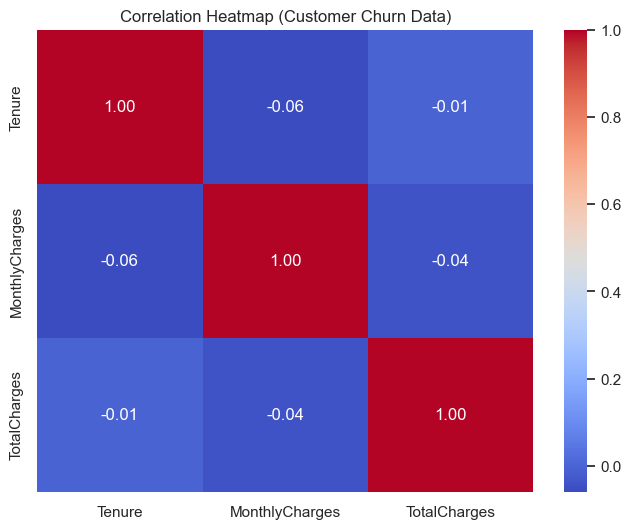

Correlation between Tenure and Total Charges: -0.01


In [28]:
# Calculate Correlation Matrix for Churn Data
corr_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df_churn[corr_cols].corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Customer Churn Data)')
plt.show()

# Print specific correlation
print(f"Correlation between Tenure and Total Charges: {corr_matrix.loc['Tenure', 'TotalCharges']:.2f}")

In [29]:
print("Hypothesis Testing")

# TEST 1: T-Test (Churned vs Non-Churned Monthly Charges)
churn_yes = df_churn[df_churn['Churn'] == 1]['MonthlyCharges']
churn_no = df_churn[df_churn['Churn'] == 0]['MonthlyCharges']

t_stat, p_val_t = stats.ttest_ind(churn_yes, churn_no)
print(f"Test 1 (T-Test): p-value = {p_val_t:.4e}")
if p_val_t < 0.05:
    print("   -> Result: SIGNIFICANT difference in charges between churn groups.")
else:
    print("   -> Result: NO significant difference.")

# TEST 2: ANOVA (Sales across Regions)
regions = [group['Total_Sales'].values for name, group in df_sales.groupby('Region')]
f_stat, p_val_a = stats.f_oneway(*regions)
print(f"\nTest 2 (ANOVA): p-value = {p_val_a:.4f}")

# Save Results to text file
with open("hypothesis_tests_results.txt", "w") as f:
    f.write(f"T-Test P-Value: {p_val_t}\nANOVA P-Value: {p_val_a}")
print("Results saved to hypothesis_tests_results.txt")

Hypothesis Testing
Test 1 (T-Test): p-value = 1.6303e-02
   -> Result: SIGNIFICANT difference in charges between churn groups.

Test 2 (ANOVA): p-value = 0.0972
Results saved to hypothesis_tests_results.txt


In [30]:
sales_data = df_sales['Total_Sales']
mean_sales = np.mean(sales_data)
sem_sales = stats.sem(sales_data) # Standard Error

# Calculate 95% CI
ci = stats.t.interval(0.95, len(sales_data)-1, loc=mean_sales, scale=sem_sales)

print("Confidence Interval Analysis")
print(f"Average Sales: ${mean_sales:,.2f}")
print(f"95% CI Range:  ${ci[0]:,.2f} to ${ci[1]:,.2f}")
print(f"Margin of Error: ±${(ci[1]-mean_sales):,.2f}")

Confidence Interval Analysis
Average Sales: $123,650.48
95% CI Range:  $103,776.35 to $143,524.61
Margin of Error: ±$19,874.13


In [31]:
# Prepare Data for Regression
X = df_sales[['Price', 'Quantity']] # Independent Variables
y = df_sales['Total_Sales']         # Dependent Variable
X = sm.add_constant(X)              # Add constant (intercept)

# Fit OLS Model
model = sm.OLS(y, X).fit()

# Show Summary
print(model.summary())

print(f"\nR-Squared Value: {model.rsquared:.4f}")

                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     369.3
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           4.40e-46
Time:                        23:52:55   Log-Likelihood:                -1185.2
No. Observations:                 100   AIC:                             2376.
Df Residuals:                      97   BIC:                             2384.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.217e+05   9668.294    -12.586      0.0